In [11]:
import pandas as pd 
from statsbombpy import sb
df = sb.events(match_id=3869685)
df.columns

Index(['50_50', 'bad_behaviour_card', 'ball_receipt_outcome',
       'ball_recovery_offensive', 'ball_recovery_recovery_failure',
       'block_deflection', 'block_offensive', 'carry_end_location',
       'clearance_aerial_won', 'clearance_body_part', 'clearance_head',
       'clearance_left_foot', 'clearance_other', 'clearance_right_foot',
       'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun',
       'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_offensive',
       'foul_committed_penalty', 'foul_committed_type', 'foul_won_advantage',
       'foul_won_defensive', 'foul_won_penalty', 'goalkeeper_body_part',
       'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position',
       'goalkeeper_technique', 'goalkeeper_type', 'id', 'index',
       'interception_outcome', 'location', 'match_id', 'minute', 'off_camera',
       'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id'

In [12]:
df = df[df['type'] == 'Pass']

In [14]:
df[['x','y']] = df['location'].apply(pd.Series)

In [15]:
df['pass_outcome'].head(10)

12    NaN
13    Out
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN
20    NaN
21    NaN
Name: pass_outcome, dtype: object

In [16]:
df = df[df['pass_outcome'].isna()]

Text(0.5, 1.0, 'France Pass Map vs Argentina')

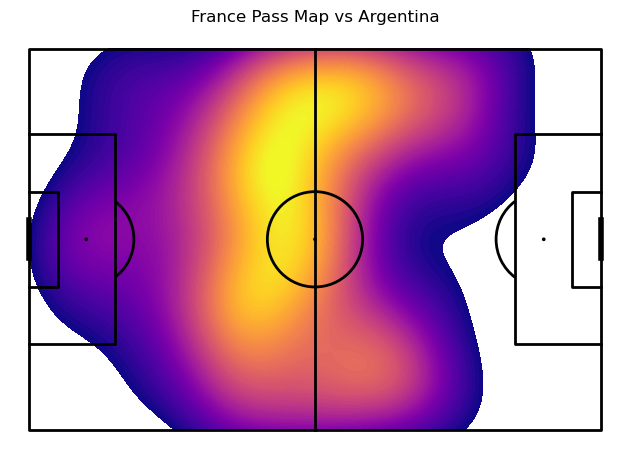

In [23]:
from mplsoccer import Pitch

pitch = Pitch(pitch_type='statsbomb',pitch_color='white',line_color='black',line_zorder=2)

fig, ax = pitch.draw()

df_arg = df[df['team_id'] == 771]

kde = pitch.kdeplot(
    df_arg.x,
    df_arg.y,
    fill=True,
    n_levels=100,
    cut=10,
    ax=ax,
    cmap='plasma'
)

ax.set_title('France Pass Map vs Argentina')